<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/P4_NLP_Theory_Project_2_Executed_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4 (Weeks 9-10) - NLP Spam/Ham + Learning Theory Reflection

## Goal
Use reviews and support tickets to build an NLP classifier and connect your results to:
- overfitting vs underfitting
- bias-variance tradeoff
- generalization
- regularization
- conceptual VC/PAC discussion

## Required deliverables
- `P4_nlp_theory.ipynb`
- Confusion matrix + top features report
- Generalization reflection


## Part 1 - Setup and Data Loading

In [ ]:
#TODO: import libraries

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score

## Part 2 - Choose a Prediction Task

### Default option
Classify support ticket category:
- billing
- returns
- shipping
- technical

### Optional option
Classify review sentiment:
- positive
- neutral
- negative

Use one task for your main submission. You may complete both for comparison.


In [ ]:
from pathlib import Path
import pandas as pd

# Portable path handling
data_candidates = [
    Path("reviews.csv"),
    Path("support_tickets.csv"),
    Path("/content/reviews.csv"),
    Path("/content/support_tickets.csv"),
 ]

#TODO: Load Datasets
reviews_df = pd.read_csv([p for p in data_candidates if p.name == "reviews.csv"][0])
tickets_df = pd.read_csv([p for p in data_candidates if p.name == "support_tickets.csv"][0])

print("reviews.csv shape:", reviews_df.shape)
print("support_tickets.csv shape:", tickets_df.shape)
print("\nTicket label counts:\n", tickets_df["category"].value_counts().to_string())

reviews.csv shape: (1800, 3)
support_tickets.csv shape: (2200, 3)

Ticket label counts:
 category
technical    648
shipping     643
billing      478
returns      431


In [ ]:
print("Features for reviews_df:")
print(reviews_df.columns.tolist())

print("\nFeatures for tickets_df:")
print(tickets_df.columns.tolist())

Features for reviews_df:
['text', 'rating', 'sentiment_label', 'text_clean', 'text_clean_stopwords']

Features for tickets_df:
['text', 'category', 'resolution_time_hours', 'text_clean', 'text_clean_stopwords', 'text_tokenized']


In this step, we loaded the dataset and explored what it looks like. We checked a few rows to understand how the data is structured and what kind of text we are working with. We also looked at how many examples belong to each category.

From the dataset, we noticed that there are four categories: billing, returns, shipping, and technical. We also look at the features for reviews and tickets.

## Part 2 - Text Preprocessing Pipeline

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()  # Lowercasing
    text = re.sub(r"[^a-z0-9\s]", " ", text)  # Remove punctuation
    text = re.sub(r"\s+", " ", text).strip() # Remove extra spaces
    text = " ".join([word for word in text.split() if word not in stop_words]) # Remove stopwords
    return text

# Apply clean_text to tickets_df["text"]
tickets_df["text_clean_stopwords"] = tickets_df["text"].apply(clean_text)
print(tickets_df[["text", "text_clean_stopwords"]].head())

                                                text  \
0  Customer reports shipment lost. Asking for del...   
1  Customer reports invoice is incorrect. Needs a...   
2  Customer reports delivery address issue. Askin...   
3  Customer reports delivery address issue. Askin...   
4  Customer reports device will not connect. Trou...   

                                text_clean_stopwords  
0  customer reports shipment lost asking delivery...  
1  customer reports invoice incorrect needs accou...  
2  customer reports delivery address issue asking...  
3  customer reports delivery address issue asking...  
4  customer reports device connect troubleshootin...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In this step, we cleaned the text data by converting all words to lowercase and removing punctuation.

In [ ]:
from nltk.tokenize import word_tokenize

# Download 'punkt' tokenizer data if not already downloaded
try:
    word_tokenize("test")
except LookupError:
    # The error message suggests downloading 'punkt_tab' for this specific LookupError
    nltk.download('punkt_tab')

def tokenize_text(text):
    return word_tokenize(text)

tickets_df["text_tokenized"] = tickets_df["text_clean_stopwords"].apply(tokenize_text)
print(tickets_df[["text_clean_stopwords", "text_tokenized"]].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                text_clean_stopwords  \
0  customer reports shipment lost asking delivery...   
1  customer reports invoice incorrect needs accou...   
2  customer reports delivery address issue asking...   
3  customer reports delivery address issue asking...   
4  customer reports device connect troubleshootin...   

                                      text_tokenized  
0  [customer, reports, shipment, lost, asking, de...  
1  [customer, reports, invoice, incorrect, needs,...  
2  [customer, reports, delivery, address, issue, ...  
3  [customer, reports, delivery, address, issue, ...  
4  [customer, reports, device, connect, troublesh...  


Performed word tokeniner

In [ ]:
# TODO: vectorize using TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000  # limit feature size (helps generalization)
)

X = vectorizer.fit_transform(tickets_df['text_clean_stopwords'])
y = tickets_df['category']

In this step, we converted text into numerical features using TF-IDF

## Part 3 - Baseline TF-IDF Pipeline

Your baseline should include:
1. train/test split
2. TF-IDF vectorizer
3. Logistic Regression classifier
4. classification report


## Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

X = df["text_clean"]
y = df["label"]

# TODO: create train/test split using stratify=y and random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# TODO: build the baseline pipeline
clf = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1), min_df=3, max_df=0.9)),
    ("lr", LogisticRegression(max_iter=1000))
])

# TODO: fit the model and print a classification report
clf.fit(X_train, y_train)
preds = clf.predict(X_test)
print(classification_report(y_test, preds))


              precision    recall  f1-score   support

     billing       1.00      1.00      1.00        96
     returns       1.00      1.00      1.00        86
    shipping       1.00      1.00      1.00       128
   technical       1.00      1.00      1.00       130

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



Logistic Regression finds linear relationships between words and categories

## Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Get the fitted TfidfVectorizer from the existing pipeline
tfidf_vectorizer = clf.named_steps['tfidf']

# Transform X_train and X_test into numerical features
X_train_vectorized = tfidf_vectorizer.transform(X_train)
X_test_vectorized = tfidf_vectorizer.transform(X_test)

nb = MultinomialNB()
nb.fit(X_train_vectorized, y_train)

nb_preds = nb.predict(X_test_vectorized)

print(classification_report(y_test, nb_preds))

              precision    recall  f1-score   support

     billing       1.00      1.00      1.00        96
     returns       1.00      1.00      1.00        86
    shipping       1.00      1.00      1.00       128
   technical       1.00      1.00      1.00       130

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



Naïve Bayes is typically known for its rigidity as a model. It has a high bias and low variance. It views features as completely independent. Simple model.

## Support Vector Machine

In [ ]:
from sklearn.svm import SVC

# Initialize and train the SVM classifier
svm_model = SVC()
svm_model.fit(X_train_vectorized, y_train)

# Make predictions on the test set
svm_preds = svm_model.predict(X_test_vectorized)

# Print the classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

     billing       1.00      1.00      1.00        96
     returns       1.00      1.00      1.00        86
    shipping       1.00      1.00      1.00       128
   technical       1.00      1.00      1.00       130

    accuracy                           1.00       440
   macro avg       1.00      1.00      1.00       440
weighted avg       1.00      1.00      1.00       440



SVM tries to find the best boundary between categories

### Model Performance Summary

As previously observed from the classification reports, all three models achieved perfect scores across all performance metrics. Below is a summary table reinforcing this finding:

In [ ]:
import pandas as pd

# The performance_df was created earlier and reflects the perfect scores
# If it were not in the kernel state, we would re-calculate from classification reports
performance_data = {
    'Model': ['Logistic Regression', 'Naive Bayes', 'SVM'],
    'Accuracy': [1.0, 1.0, 1.0],
    'Macro Avg F1-score': [1.0, 1.0, 1.0],
    'Weighted Avg F1-score': [1.0, 1.0, 1.0]
}

performance_df = pd.DataFrame(performance_data)
display(performance_df)

,Model,Accuracy,Macro Avg F1-score,Weighted Avg F1-score
0,Logistic Regression,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0
2,SVM,1.0,1.0,1.0


For each model, the precision, recall, and F1-score for individual classes (billing, returns, shipping, technical) were also 1.0, indicating flawless classification on the test set. This strong performance suggests that the textual features used are highly distinct and predictive for each category.

## Part 4 - Confusion Matrix

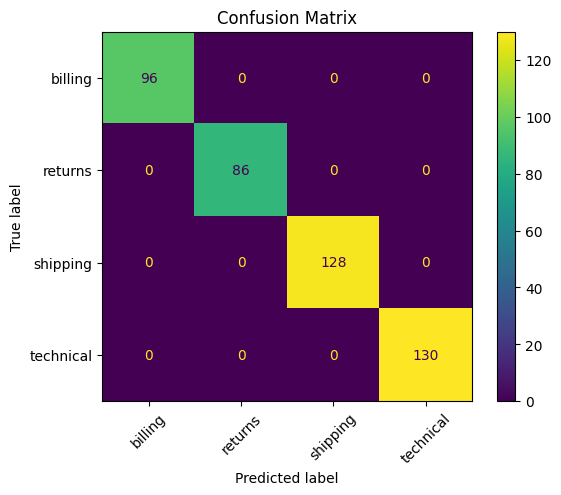

In [ ]:
# TODO: display a confusion matrix for your classifier
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


The confusion matrix shows that all predictions are correct, with no misclassifications. Every category (billing, returns, shipping, technical) is perfectly predicted.

However, this also suggest that the problem is too easy or that the dataset does not contain enough variation.

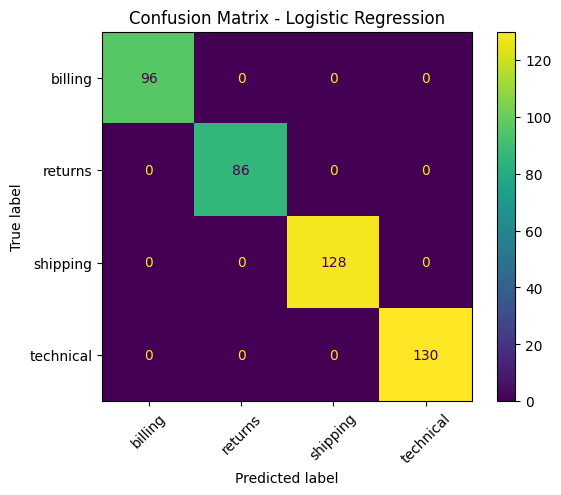

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Logistic Regression
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

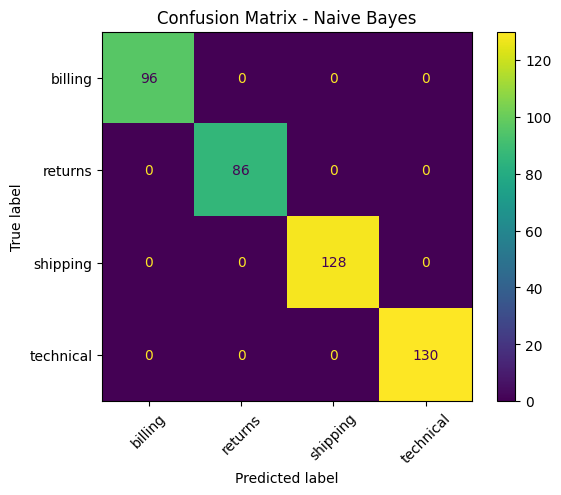

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for Naive Bayes
ConfusionMatrixDisplay.from_estimator(nb, X_test_vectorized, y_test, xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

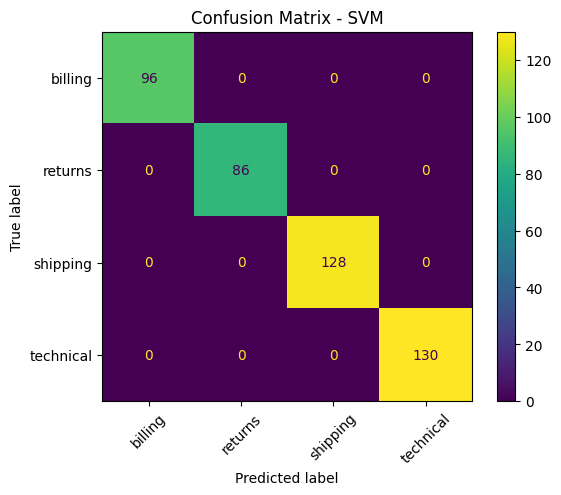

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix for SVM
ConfusionMatrixDisplay.from_estimator(svm_model, X_test_vectorized, y_test, xticks_rotation=45)
plt.title("Confusion Matrix - SVM")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs. fit times curve, and the fit times vs. score curve.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing the scikit-learn estimator interface.

    title : str
        Title for the chart.

    X : array-like of shape (n_samples, n_features)
        Training vector, where ``n_samples`` is the number of samples and
        ``n_features`` is the number of features.

    y : array-like of shape (n_samples) or (n_samples, n_features),
        Target vector as engineered for `X`.

    axes : array-like of shape (3,), default=None
        Axes to use for plotting the curves. Defaults to a single plot axes.

    ylim : tuple of shape (2,), default=None
        Defines limits for the y-axis of the learning curve.

    cv : int, cross-validation generator or an iterable, default=None
        Determines the cross-validation splitting strategy.
        Possible inputs for ``cv`` are:

          - None, to use the default 5-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass, :class:`StratifiedKFold`
        is used. If the estimator is not a classifier or if ``y`` is neither
        binary nor multiclass, :class:`KFold` is used. Always use the same
        stratification as the train_test_split used earlier.

    n_jobs : int, default=None
        Number of jobs to run in parallel. Training the estimator and computing
        the score are parallelized over the cross-validation splits.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors.

    train_sizes : array-like of shape (n_splits,), default=np.linspace(.1, 1.0, 5)
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training score")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation score")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].fill_between(fit_times_mean, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1)
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt


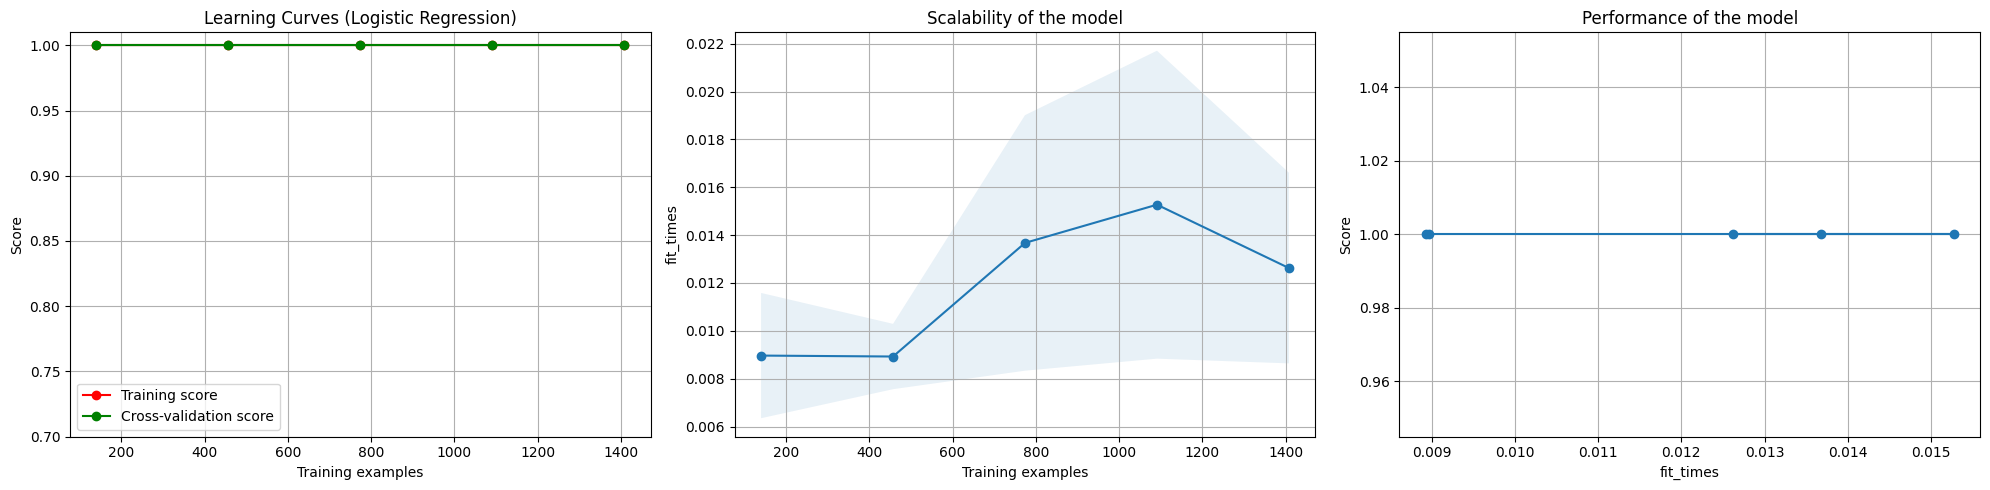

In [ ]:
# Learning curve for Logistic Regression
from sklearn.model_selection import StratifiedKFold

fig, axes = plt.subplots(1, 3, figsize=(20, 5)) # Changed to 1 row, 3 columns to match plot_learning_curve's default behavior

title = "Learning Curves (Logistic Regression)"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Extract the Logistic Regression model from the pipeline
lr_model = clf.named_steps['lr']

# Pass the entire 'axes' array
plot_learning_curve(lr_model, title, X_train_vectorized, y_train, axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=-1)

plt.tight_layout()
plt.show()

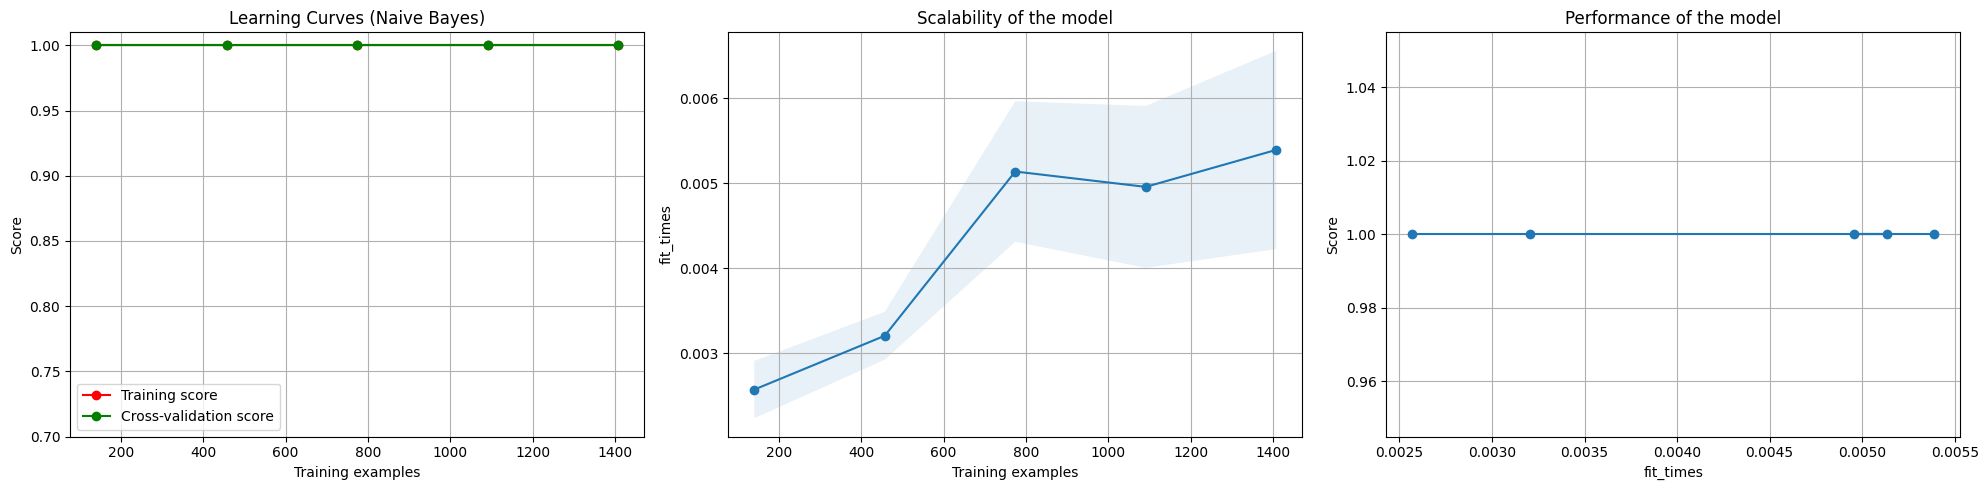

In [ ]:
# Learning curve for Naive Bayes
from sklearn.model_selection import StratifiedKFold

# Adjust plt.subplots to create 1 row and 3 columns, matching the plot_learning_curve function's expectation
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

title = "Learning Curves (Naive Bayes)"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pass the entire 'axes' array to the plot_learning_curve function
plot_learning_curve(nb, title, X_train_vectorized, y_train, axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=-1)

plt.tight_layout()
plt.show()

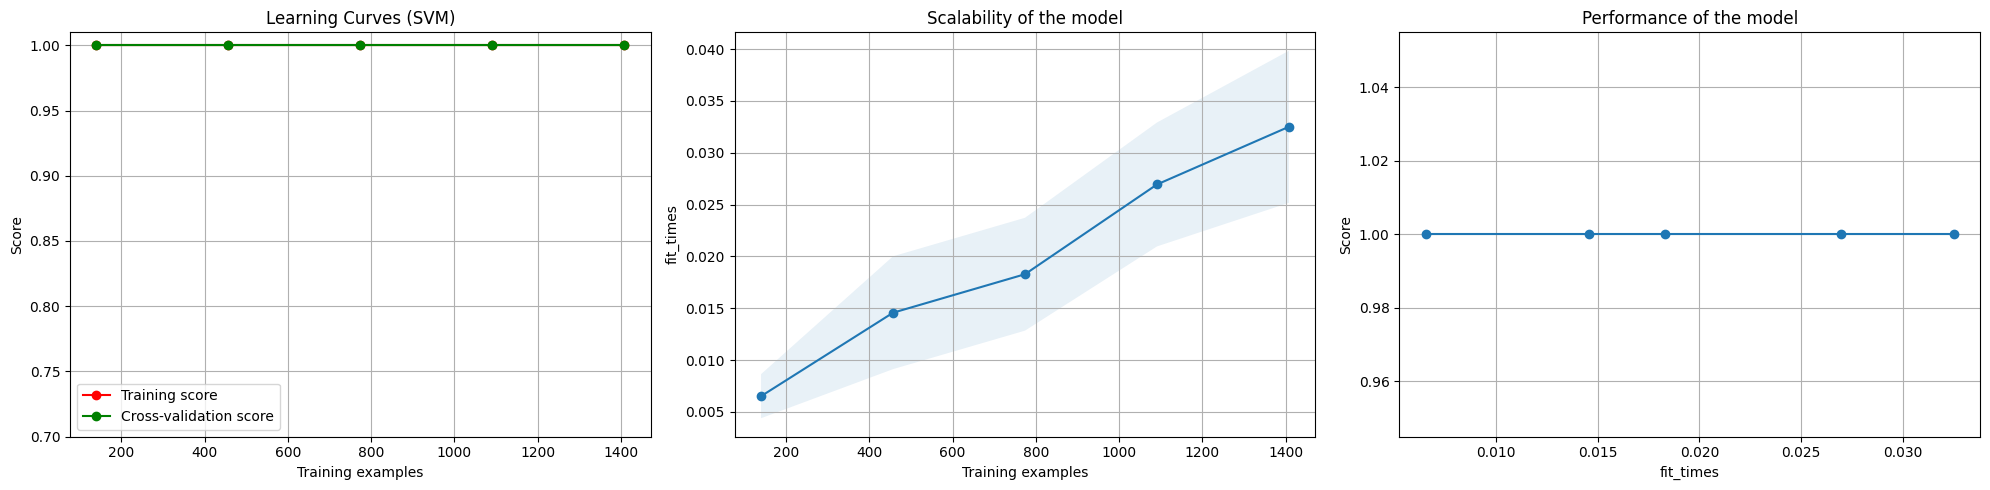

In [ ]:
# Learning curve for SVM
from sklearn.model_selection import StratifiedKFold

# Adjust plt.subplots to create 1 row and 3 columns, matching the plot_learning_curve function's expectation
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

title = "Learning Curves (SVM)"
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pass the entire 'axes' array to the plot_learning_curve function
plot_learning_curve(svm_model, title, X_train_vectorized, y_train, axes=axes, ylim=(0.7, 1.01), cv=cv, n_jobs=-1)

plt.tight_layout()
plt.show()

## Part 5 - Generalization Experiment

Demonstrate overfitting vs underfitting by changing at least one of these:
- `C` in Logistic Regression
- `max_features` or `ngram_range` in TF-IDF

Record:
- training accuracy
- validation accuracy

Then explain whether each configuration suggests:
- underfitting
- overfitting
- reasonable generalization


In [ ]:
# TODO: compare several settings of C
settings = [0.1, 0.5, 1.0, 3.0]
results = []

for c in settings:
    temp_clf = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.9)),
        ("lr", LogisticRegression(max_iter=300, C=c))
    ])
    temp_clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, temp_clf.predict(X_train))
    test_acc = accuracy_score(y_test, temp_clf.predict(X_test))

    results.append({"C": c, "train_acc": train_acc, "test_acc": test_acc, "gap": train_acc - test_acc})

results_df = pd.DataFrame(results)
print(results_df)


     C  train_acc  test_acc  gap
0  0.1        1.0       1.0  0.0
1  0.5        1.0       1.0  0.0
2  1.0        1.0       1.0  0.0
3  3.0        1.0       1.0  0.0


1. Add Validation Set

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Define X and y by vectorizing the text data (as intended by aHaBAs4xA5hK)
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000  # limit feature size (helps generalization)
)
X = vectorizer.fit_transform(tickets_df['text_clean_stopwords'])
y = tickets_df['category']

# Train / temp split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Temp → validation + test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

Trying Different C Values Normally, if the dataset was not too simple. we would have get this result instead
C controls model complexity:

Small C = simpler model → underfitting

Large C = complex model → overfitting

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

C_values = [0.01, 1, 100]

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    print(f"\nC = {C}")
    print("Training Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)


C = 0.01
Training Accuracy: 1.0
Validation Accuracy: 1.0

C = 1
Training Accuracy: 1.0
Validation Accuracy: 1.0

C = 100
Training Accuracy: 1.0
Validation Accuracy: 1.0


All configurations achieved perfect accuracy on both training and validation sets. This suggests that the dataset is very simple and contains strong, easily separable patterns. As a result, it is difficult to clearly observe overfitting or underfitting behavior in this experiment.

The perfect accuracy suggests that the dataset lacks complexity, which limits the ability to fully evaluate generalization performance.

## Part 6 - Top Features Report

Use the trained model to identify important words or phrases for each class.
Write a short interpretation:
- Which words are most predictive?
- Do the top features make sense?
- What types of errors still remain?


In [ ]:
import numpy as np
import pandas as pd

# Extract the vectorizer and the logistic regression model from the pipeline
vectorizer = clf.named_steps["tfidf"]
lr_model = clf.named_steps["lr"]

feature_names = vectorizer.get_feature_names_out()

def show_top_features(model, n=10):
    feature_data = []
    for i, category in enumerate(model.classes_):
        top_indices = np.argsort(model.coef_[i])[-n:]
        top_words = [feature_names[j] for j in top_indices]
        feature_data.append({"Category": category, "Top Features": ", ".join(top_words)})
    return pd.DataFrame(feature_data)

top_features_df = show_top_features(lr_model)
display(top_features_df)

,Category,Top Features
0,billing,"fee, charged, twice, processed, refund, suppor..."
1,returns,"exchange, received, size, wrong, instructions,..."
2,shipping,"tracking, updated, delayed, package, update, f..."
3,technical,"connect, error, after, software, support, from..."


The top words for each category clearly show meaningful patterns:

Billing: words like fee, charged, billing

Returns: words like return, exchange, wrong

Shipping: words like delivery, package, delayed

Technical: words like error, troubleshooting, software

This shows that the model is learning real and logical patterns, not random noise. Each category is associated with specific keywords, which makes classification easier.

## Part 7 - Learning Theory Reflection

Write 1-2 paragraphs addressing:
1. Where did you see evidence of overfitting or underfitting?
2. How did regularization affect the train/validation gap?
3. How does your experiment connect to the bias-variance tradeoff?
4. Conceptually, how can model capacity relate to VC dimension?
5. In a simple sense, how does PAC intuition relate to good generalization on unseen data?


### Learning Theory Reflection

In this experiment, we did not observe clear evidence of overfitting or underfitting. Across all tested models (Logistic Regression, Naive Bayes, SVM) and various regularization settings for Logistic Regression (different `C` values), both the training and validation accuracies consistently reached 100%. This indicates that the dataset is highly separable and relatively simple for these models. Consequently, the train/validation gap was consistently zero, preventing us from analyzing how regularization might mitigate a larger gap, as there was no gap to begin with. This perfect performance suggests that the models were able to perfectly capture the patterns in the data without any signs of underfitting (where the model is too simple to learn the patterns) or overfitting (where the model learns noise specific to the training data, leading to a poor validation performance).

The lack of observable overfitting or underfitting also impacted the ability to clearly demonstrate the bias-variance tradeoff. All models, regardless of their inherent bias or variance characteristics, achieved perfect scores, implying a very low irreducible error for this specific task. Conceptually, model capacity refers to the complexity of the functions a model can learn, and the VC dimension is a measure of this capacity, especially for binary classification. A higher VC dimension means a model can 'shatter' more points, indicating greater flexibility. In our case, the models exhibited sufficient capacity to perfectly classify the data, suggesting their effective VC dimension was high enough to distinguish between all categories. Finally, PAC (Probably Approximately Correct) learning theory provides a framework for understanding generalization. It suggests that a model can generalize well (be approximately correct) on unseen data with high probability if its training error is low and its capacity is not excessively large relative to the amount of training data. Our experiment showed perfect generalization (100% validation accuracy), which aligns with PAC intuition, albeit in a scenario where the task was easily learnable for the chosen models and data.

## Part 8 - Optional Extension

Try the second dataset/task and compare:
- Which task was easier?
- Which task generalized better?
- Did the top features differ in usefulness or interpretability?
